# Logistic Regression

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Read Dataset

In [3]:
# Load the dataset
data = pd.read_csv('preprocessed_loan_data.csv')

data.head()

,loan_percent_income,loan_int_rate,cb_person_cred_hist_length,person_age,credit_score,person_emp_exp,person_education_Associate,person_education_Bachelor,person_education_Doctorate,person_education_High School,...,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_gender,previous_loan_defaults_on_file,loan_status
0,1.000000,0.715620,0.087589,0.14898,0.250733,0.000000,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0
1,0.175824,0.401104,0.014596,0.10092,0.058291,0.000000,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,1
2,0.967033,0.512603,0.087589,0.29316,0.500570,0.162162,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0
3,0.967033,0.664705,0.014596,0.19704,0.635617,0.000000,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0
4,1.000000,0.602833,0.160582,0.24510,0.335137,0.054054,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0,0


In [4]:
#shape
data.shape

(70000, 24)

# Split the data

In [5]:
# Separate feature columns and target column
X = data.drop('loan_status', axis=1)   # All columns except the target
Y = data['loan_status']                # Target column

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20)

In [7]:
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (56000, 23)
Testing set shape: (14000, 23)


In [8]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [9]:
lr.score(X_test, y_test)

0.8821428571428571

## Hyperparameter Tuning - GridSearchCV (Logistic Regression)

In [10]:
from sklearn.model_selection import GridSearchCV

# Grid 1
param_grid_log_1 = {
    'C': [0.1, 1, 10], 
    'max_iter': [100, 200]
}

# Grid 2
param_grid_log_2 = {
    'C': [0.01, 0.1, 1], 
    'max_iter': [200, 500]
}

# Grid 3
param_grid_log_3 = {
    'C': [1, 10, 100], 
    'max_iter': [500, 1000]
}

In [11]:
# Grid 1
grid_logreg_1 = GridSearchCV(estimator=lr, param_grid=param_grid_log_1, cv = 10)
grid_logreg_1.fit(X_train, y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [0.1, 1, ...], 'max_iter': [100, 200]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [12]:
grid_logreg_1.best_params_

{'C': 0.1, 'max_iter': 100}

In [13]:
grid_logreg_1.score(X_test, y_test)

0.8816428571428572

In [14]:
#Grid 2
grid_logreg_2 = GridSearchCV(estimator=lr, param_grid=param_grid_log_2, cv = 10)
grid_logreg_2.fit(X_train, y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [0.01, 0.1, ...], 'max_iter': [200, 500]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [15]:
grid_logreg_2.best_params_

{'C': 0.1, 'max_iter': 200}

In [16]:
grid_logreg_2.score(X_test, y_test)

0.8816428571428572

In [17]:
# Grid 3
grid_logreg_3 = GridSearchCV(estimator=lr, param_grid=param_grid_log_3, cv = 10)
grid_logreg_3.fit(X_train, y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [1, 10, ...], 'max_iter': [500, 1000]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [18]:
grid_logreg_3.best_params_

{'C': 1, 'max_iter': 500}

In [19]:
grid_logreg_3.score(X_test, y_test)

0.8821428571428571

In [20]:
# Evaluation Metrics

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# List of trained GridSearchCV models
grids = [grid_logreg_1, grid_logreg_2, grid_logreg_3]
grid_names = ["Logistic Grid 1", "Logistic Grid 2", "Logistic Grid 3"]

# Prepare empty list to store results
results = []

for name, grid in zip(grid_names, grids):
    y_pred = grid.predict(X_test)   # Predict on test set
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, acc, prec, rec, f1])

# Create DataFrame
df_log = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])

# Display
df_log

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Grid 1,0.881643,0.907797,0.846875,0.876279
1,Logistic Grid 2,0.881643,0.907797,0.846875,0.876279
2,Logistic Grid 3,0.882143,0.905266,0.850916,0.877250


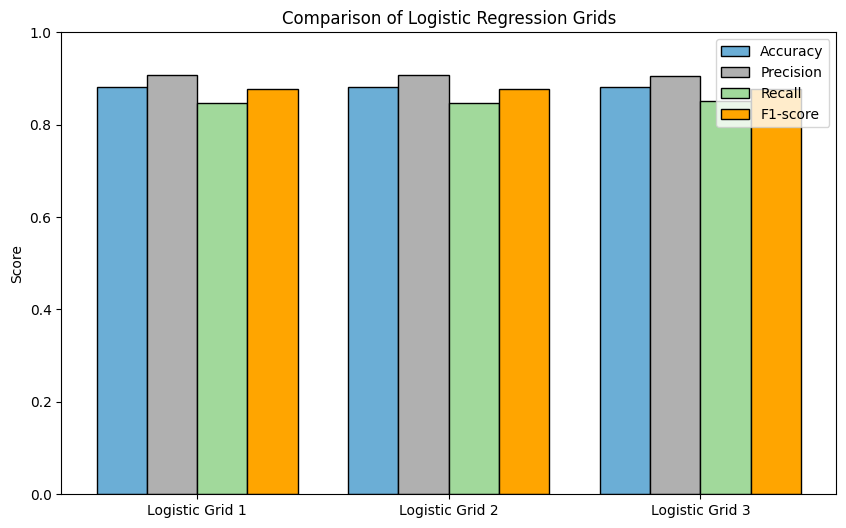

In [22]:
plt.figure(figsize=(10,6))

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = range(len(df_log))
width = 0.2

# Define different colors for each metric
colors = ['#6BAED6', '#B0B0B0', '#A1D99B', 'orange']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    plt.bar([p + width*i for p in x], df_log[metric], width=width, label=metric, color=color, edgecolor = 'black')

plt.xticks([p + 1.5*width for p in x], df_log["Model"])
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Comparison of Logistic Regression Grids")
plt.legend()
plt.show()